# 02 — Phase-1 BIST100 strategy comparison

**Inputs:** `results/phase1_sweep.parquet`, `results/phase1_mc.parquet`, `results/phase1_mc_distributions.parquet`, `data/clean/XU100.IS.parquet`.

**Outputs for the deck:** Phase-1 winners table, four-strategy equity overlay vs buy-and-hold, MC Sharpe histograms (one per strategy) with the strategy Sharpe as a vertical line.

Window: BIST100 Index over `config.START_DATE` through today (≈11 years of daily bars on the 2015-start slice).

This is the "we picked HP" notebook (HP primary on theoretical grounds; LOWESS narrowly empirically better — both reported).

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.plots.figures import apply_style, equity_curve_overlay, mc_distribution
from config import BIST100_INDEX_TICKER, CLEAN_DIR, RESULTS_DIR

apply_style()

## 1. Phase-1 sweep — winners table

Load `phase1_sweep.parquet`, filter to `enough_trades == True`, then pick the highest-Sharpe row per strategy. Headline ordering (LOWESS > HP > EMA-direction > EMA-crossover) is the same one CLAUDE.md anchored on; the exact Sharpes shift each time the universe or window changes, so read the table below rather than the prose.

In [2]:
sweep = pd.read_parquet(RESULTS_DIR / "phase1_sweep.parquet")
elig = sweep[sweep["enough_trades"]].copy()

def _params_str(row):
    if row["strategy"] == "S1_ema_crossover":
        return f"n_fast={int(row['n_fast'])}, n_slow={int(row['n_slow'])}"
    if row["strategy"] == "S2_ema_direction":
        return f"n={int(row['n'])}"
    if row["strategy"] == "S3_hp_direction":
        return f"λ={int(row['lam'])}, window={int(row['window'])}"
    if row["strategy"] == "S4_lowess_direction":
        return f"frac={row['frac']:.2f}, window={int(row['window'])}"
    return ""

winners = (
    elig.sort_values("sharpe", ascending=False)
        .groupby("strategy", as_index=False)
        .first()
)
winners["params"] = winners.apply(_params_str, axis=1)
table = winners[["strategy", "params", "sharpe", "n_trades", "cagr",
                 "max_drawdown", "calmar"]].sort_values("sharpe", ascending=False)
table = table.round({"sharpe": 3, "cagr": 4, "max_drawdown": 4, "calmar": 3})
print(f"Phase-1 sweep configs evaluated: {len(sweep)} (with ≥30 trades: {len(elig)})")
print()
print(table.to_string(index=False))

Phase-1 sweep configs evaluated: 41 (with ≥30 trades: 35)

           strategy                params  sharpe  n_trades   cagr  max_drawdown  calmar
S4_lowess_direction frac=0.05, window=252   1.377       402 0.3466       -0.2502   1.385
    S3_hp_direction     λ=100, window=252   1.257       356 0.3140       -0.3020   1.040
   S2_ema_direction                  n=10   1.134       311 0.2835       -0.3268   0.867
   S1_ema_crossover n_fast=10, n_slow=100   0.844        31 0.1944       -0.3185   0.610


## 2. Equity curves at the Phase-1 winning params

For each strategy's winning param set, re-run the backtest on BIST100 to obtain the equity curve (the sweep parquet stores summary metrics only, not curves). Then overlay all four with buy-and-hold via `equity_curve_overlay`.

Re-running is fine — single index, single config per strategy, total runtime ≈ a few minutes (HP rolling is the slow one).

Running 4 backtests on BIST100 Index (HP & LOWESS are slow — ~1-3 min total)...


  S1 EMA xover (5/100): trades=  39  final=3.763x


  S2 EMA dir (n=10): trades= 311  final=7.980x


  S3 HP (λ=14400, w=504): trades= 171  final=3.858x


  S4 LOWESS (frac=0.2, w=252): trades= 178  final=6.511x


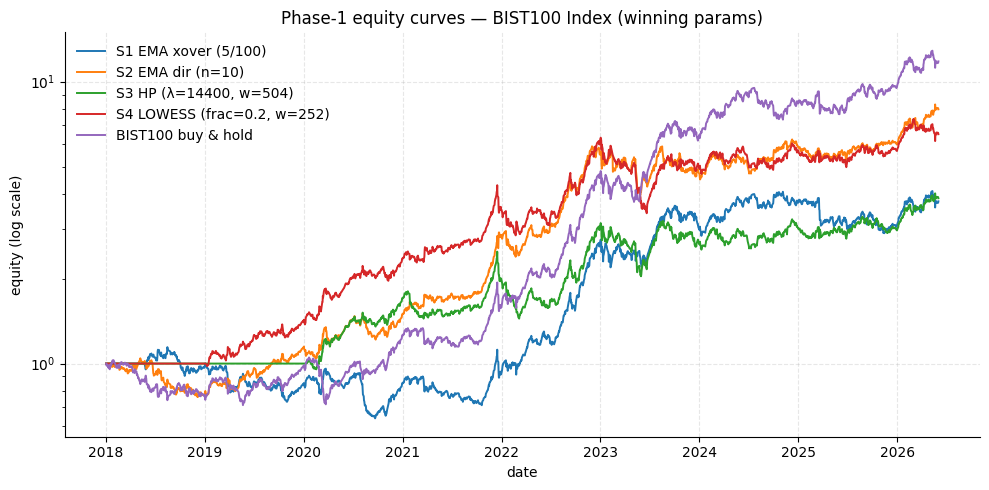

In [3]:
from src.backtest.runner import run_backtest
from src.features.ema import ema_crossover_signal, ema_direction_signal
from src.features.hp import hp_direction_signal
from src.features.lowess import lowess_direction_signal

bist = pd.read_parquet(CLEAN_DIR / f"{BIST100_INDEX_TICKER}.parquet")
close = bist["close"]

# Phase-1 winners (from CLAUDE.md / cell above)
sigs = {
    "S1 EMA xover (5/100)":      ema_crossover_signal(close, n_fast=5, n_slow=100),
    "S2 EMA dir (n=10)":          ema_direction_signal(close, n=10),
    "S3 HP (λ=14400, w=504)":    hp_direction_signal(close, lam=14400, window=504),
    "S4 LOWESS (frac=0.2, w=252)": lowess_direction_signal(close, frac=0.2, window=252),
}

curves = {}
print("Running 4 backtests on BIST100 Index (HP & LOWESS are slow — ~1-3 min total)...")
for label, sig in sigs.items():
    res = run_backtest(bist, sig)
    eq = res.equity_curve
    curves[label] = eq / eq.iloc[0]
    print(f"  {label}: trades={len(res.trades):4d}  final={res.final_value/res.initial_value:.3f}x")

# Buy-and-hold of the index, normalised to start at 1.0
bh = close / close.iloc[0]
curves["BIST100 buy & hold"] = bh.reindex(next(iter(curves.values())).index)

from src.plots.figures import equity_curve_overlay
ax = equity_curve_overlay(curves, log=True,
                          title="Phase-1 equity curves — BIST100 Index (winning params)")
plt.tight_layout()
plt.show()

## 3. Monte Carlo Sharpe histograms

Loop over the four strategies, pull the row from `phase1_mc.parquet` for the strategy Sharpe and N, and the column from `phase1_mc_distributions.parquet` for the empirical MC pool. One `mc_distribution(...)` call per strategy → 2×2 grid of histograms.

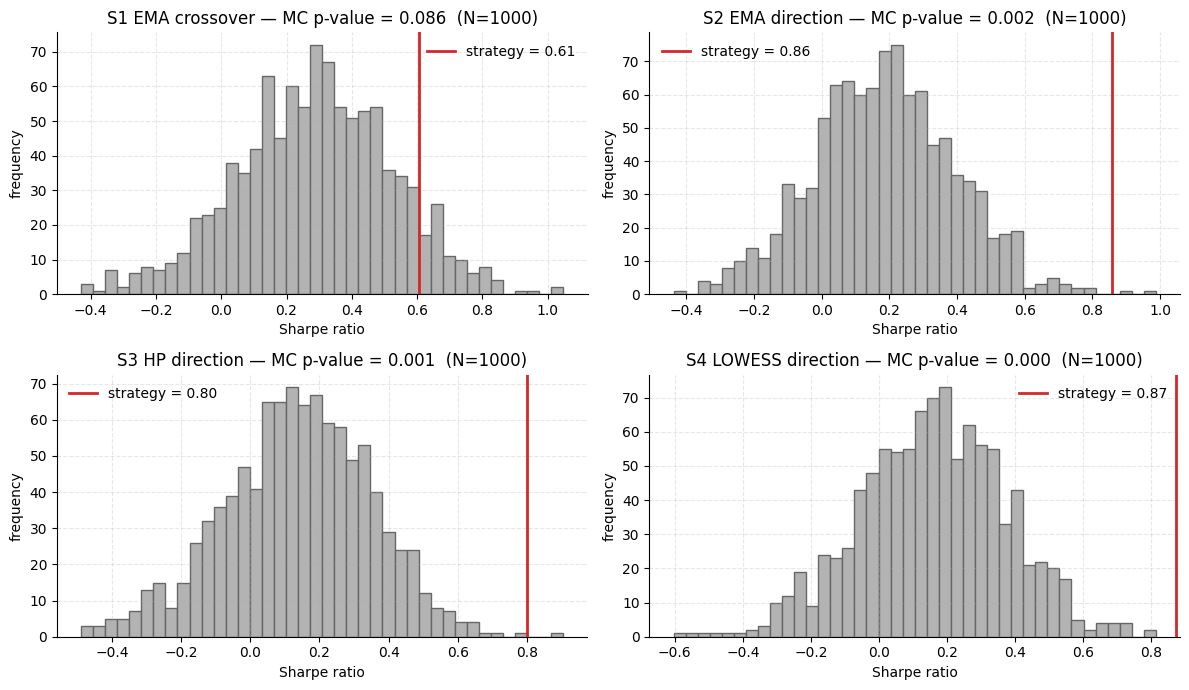


                     strat_sharpe  mc_sharpe_mean  mc_sharpe_q95  p_value
strategy                                                                 
S1_ema_crossover            0.605           0.286          0.668    0.086
S2_ema_direction            0.858           0.186          0.537    0.002
S3_hp_direction             0.801           0.136          0.469    0.001
S4_lowess_direction         0.875           0.160          0.505    0.000


In [4]:
mc = pd.read_parquet(RESULTS_DIR / "phase1_mc.parquet")
mc_dist = pd.read_parquet(RESULTS_DIR / "phase1_mc_distributions.parquet")

order = ["S1_ema_crossover", "S2_ema_direction", "S3_hp_direction", "S4_lowess_direction"]
labels = {
    "S1_ema_crossover": "S1 EMA crossover",
    "S2_ema_direction": "S2 EMA direction",
    "S3_hp_direction":  "S3 HP direction",
    "S4_lowess_direction": "S4 LOWESS direction",
}

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, strat in zip(axes.flatten(), order):
    row = mc[mc["strategy"] == strat].iloc[0]
    mc_distribution(row["strat_sharpe"], mc_dist[strat].to_numpy(),
                    label=labels[strat], bins=40, ax=ax)
plt.tight_layout()
plt.show()

print()
print(mc.set_index("strategy").loc[order, ["strat_sharpe", "mc_sharpe_mean",
                                            "mc_sharpe_q95", "p_value"]]
        .round({"strat_sharpe": 3, "mc_sharpe_mean": 3,
                "mc_sharpe_q95": 3, "p_value": 4}))

## 4. Reading

The qualitative story is stable across windows: the three direction-of-trend strategies (S2 EMA-direction, S3 HP, S4 LOWESS) reject random at conventional thresholds, while the classical fast/slow EMA crossover (S1) sits near the marginal-significance line. S3 HP is reported as the **primary** strategy on theoretical grounds (Harris–Yilmaz LF-filter argument); S4 LOWESS is carried as the **empirical benchmark** and is consistently the highest-Sharpe sweep winner.